## Использованные данные

В данной работе применены те же алгоритмы проверки градиента, что и в лекции, но на другом наборе данных.

**Вместо датасета wine:**
- датасет `Iris` из sklearn
- 4 признака (длина и ширина чашелистика и лепестка)
- 150 наблюдений, 3 класса (setosa, versicolor, virginica)

Архитектура сети сохранена: input(4) → hidden(16) → hidden(16) → output(3), но количество параметров уменьшилось с 547 до **403** из-за меньшего числа входных признаков (4 вместо 13).

# Проверка градиента

# Простые примеры
## Один параметр
Вначале приведем простой пример с одним параметром. Рассмотрим следующую
функцию потерь.

$$ f(\theta) = \theta^2 $$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

In [2]:
def f(theta):
  return theta ** 2

Производная этой функции равна $ f'(\theta) = 2 \theta .$

In [3]:
def derivative(theta):
  return 2 * theta

Положим $ \theta = 3 $ и найдем значение производной в этой точке.
$$ f'(3) = 2 \cdot 3 = 6 $$

In [4]:
theta = 3
deriv = derivative(3)
deriv

6

Это первый компонент. Теперь выполним численную оценку производной в этой
же точке, положив $\varepsilon = 1\mathrm{e}{-7}.$

$$ f’_{\text{numeric}} = \frac{f(\theta + \varepsilon)-f(\theta-\varepsilon)}{2
\varepsilon} = $$

$$ \frac{f(3 + 1\mathrm{e}{-7})-f(3-1\mathrm{e}{-7})}{2 \cdot 1\mathrm{e}{-7}}
\approx 5{,}999999 $$

In [5]:
eps = 1e-7

In [6]:
derivNumeric = (f(theta + eps) - f(theta - eps)) / (2 * eps)
derivNumeric

5.999999990180527

Если разница между значением производной и ее численной оценкой меньше, чем $
\varepsilon,$ то можно считать, что производная взята верно.

In [7]:
deriv - derivNumeric, deriv - derivNumeric < eps

(9.819473234529141e-09, True)

### Два параметра

Рассмотрим функцию потерь с двумя параметрами

$$ f(\theta_1, \theta_2) = \theta_1^2 + \theta_2^2 $$

In [8]:
def f(theta1, theta2):
  return theta1 ** 2 + theta2 ** 2

и соответствующими частными производными

$$ \frac{ \partial }{ \partial \theta_1 } f( \theta_1, \theta_2 ) = 2 \theta_1, \quad \frac{
\partial }{ \partial \theta_2 } f( \theta_1, \theta_2 ) = 2 \theta_2 $$

In [9]:
def partial1(theta1):
  return 2 * theta1

In [10]:
def partial2(theta2):
  return 2 * theta2

Найдем значение градиента в точке $(3, 4).$

$$ \nabla f( 3, 4 ) = \begin{bmatrix} \frac{ \partial }{ \partial \theta_1 } \\ \frac{ \partial
}{ \partial \theta_1 } \end{bmatrix} f( 3, 4 ) = \begin{bmatrix} 2 \cdot 3 \\ 2 \cdot 4
\end{bmatrix} = \begin{bmatrix} 6 \\ 8 \end{bmatrix} $$

In [11]:
theta1, theta2 = 3, 4
grad = np.array([partial2(theta1), partial2(theta2)])
grad

array([6, 8])

Численную оценку при этом будем проводить, находя отношение приращений
отдельно по каждому измерению

$$ \frac{ \partial }{ \partial \theta_1 } f( \theta_1, \theta_2 ) \approx \frac{ f( \theta_1 +
\varepsilon, \theta_2 )-(\theta_1-\varepsilon, \theta_2) }{ 2\varepsilon } $$

$$ \frac{ \partial }{ \partial \theta_2 } f( \theta_1, \theta_2 ) \approx \frac{ f( \theta_1,
\theta_2 + \varepsilon )-(\theta_1, \theta_2-\varepsilon ) }{ 2\varepsilon } $$

In [12]:
partial1Numeric = (f(theta1 + eps, theta2) - f(theta1 - eps, theta2)) / (2 * eps)
partial2Numeric = (f(theta1, theta2 + eps) - f(theta1, theta2 - eps)) / (2 * eps)

gradNumeric = np.array([partial1Numeric, partial2Numeric])
gradNumeric

array([5.99999998, 8.        ])

Оценим разницу между значением градиента и его численной оценкой по формуле

$$ \text{difference} = \frac{ || \nabla f(\theta)_{\text{numeric}}-\nabla f(\theta) ||_2 }{ ||
\nabla f(\theta)_{\text{numeric}} ||_2+|| \nabla f(\theta) ||_2} $$

В числителе мы находим евклидово расстояние разницы между фактическим
градиентом и его численной оценкой, а в знаменателе нормализуем эту разницу на
сумму длин соответствующих векторов.

In [13]:
numerator = np.linalg.norm(grad - gradNumeric)
denominator = np.linalg.norm(grad) + np.linalg.norm(gradNumeric)
difference = numerator / denominator
difference, difference < eps

(np.float64(9.637876920383396e-10), np.True_)

Перейдем к проверке частных производных нейросети.

## Проверка градиента нейросети

### Подготовка данных

In [14]:
# возьмем функцию для one-hot encoding
def ohe(y):
  examples, features = y.shape[0], len(np.unique(y))
  zeros_matrix = np.zeros((examples, features))
  for i, (row, digit) in enumerate(zip(zeros_matrix, y)):
    zeros_matrix[i][digit] = 1

  return zeros_matrix

In [15]:
# подгрузим данные
data = load_iris()

# сформируем две матрицы Numpy, в которых наблюдения будут столбцами
X = pd.DataFrame(data.data, columns=data.feature_names)
X = ((X - X.mean()) / X.std()).values.T
y = data.target
y_enc = ohe(y).T

X.shape, y_enc.shape

((4, 150), (3, 150))

Как мы видим, у нас будет 4 признака, 150 наблюдений и 3 класса целевой
переменной.

## Архитектура сети

In [16]:
A1 = X

### Необходимые функции

Объявим необходимые для данной архитектуры функции.
### Служебные функции
Начнем с функций активации, а также целевой функции.

In [17]:
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s

def softmax(z):
  z = z - np.max(z, axis = 0, keepdims = True)
  numerator = np.exp(z)
  denominator = np.sum(numerator, axis = 0, keepdims = True)
  softmax = numerator / denominator
  return softmax

def cross_entropy(probs, y_enc, epsilon = 1e-9):
  n = probs.shape[1]
  ce = -np.sum(y_enc * np.log(probs + epsilon)) / n

  return ce

Кроме этого, поместим в отдельные функции код
* инициализации параметров;
* прямого; и
* обратного распространения.

### Инициализация параметров

In [18]:
def initialize(x, y, random_state = 42):

  np.random.seed(random_state)

  parameters = {}

  parameters['W1'] = np.random.randn(16, x.shape[0])
  parameters['b1'] = np.zeros((16, 1))

  parameters['W2'] = np.random.randn(16, 16)
  parameters['b2'] = np.zeros((16, 1))

  parameters['W3'] = np.random.randn(y.shape[0], 16)
  parameters['b3'] = np.zeros((y.shape[0], 1))

  return parameters

### Прямое и обратное распространение

In [19]:
def forward(x, y, parameters):

  n = x.shape[1]

  W1 = parameters['W1']
  b1 = parameters['b1']
  W2 = parameters['W2']
  b2 = parameters['b2']
  W3 = parameters['W3']
  b3 = parameters['b3']

  Z1 = np.dot(W1, x) + b1
  A1 = sigmoid(Z1)

  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)

  Z3 = np.dot(W3, A2) + b3
  A3 = softmax(Z3)

  loss = cross_entropy(A3, y)

  cache = (A1, W1, b1, A2, W2, b2, A3, W3, b3)

  return loss, cache

In [20]:
def backward(x, y, cache, lr = 0.1):

  (A1, W1, b1, A2, W2, b2, A3, W3, b3) = cache

  n = x.shape[1]

  W3_delta = A3 - y
  W2_delta = np.dot(W3.T, W3_delta) * A2 * (1 - A2)
  W1_delta = np.dot(W2.T, W2_delta) * A1 * (1 - A1)

  W3_derivative = np.dot(W3_delta, A2.T) / n
  b3_derivative = np.sum(W3_delta, axis = 1, keepdims = True) / n

  W2_derivative = np.dot(W2_delta, A1.T) / n
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n

  W1_derivative = np.dot(W1_delta, x.T) / n
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n

  parameters = {}

  parameters['W3'] = W3 - lr * W3_derivative
  parameters['b3'] = b3 - lr * b3_derivative
  parameters['W2'] = W2 - lr * W2_derivative
  parameters['b2'] = b2 - lr * b2_derivative
  parameters['W1'] = W1 - lr * W1_derivative
  parameters['b1'] = b1 - lr * b1_derivative

  gradients = {}

  gradients['dW3'] = W3_derivative
  gradients['db3'] = b3_derivative
  gradients['dW2'] = W2_derivative
  gradients['db2'] = b2_derivative
  gradients['dW1'] = W1_derivative
  gradients['db1'] = b1_derivative

  return parameters, gradients

### Обучение и прогноз
Обучим модель, сделаем прогноз (пока без проверки градиента) и оценим его
качество.

In [21]:
def fit_nn(x, y, epochs = 1000, lr = 0.1):

  parameters = initialize(x, y)
  loss_history = []

  for i in range(epochs):

    loss, cache = forward(x, y, parameters)
    # функция backward() выдает два словаря: parameters и gradients
    # словарь gradients пока не нужен, и мы оставляем _
    parameters, _ = backward(x, y, cache, lr)

    if i % (epochs / 5) == 0:
      print('Эпоха:', i)
      print('Ошибка:', loss)
      print('-----------------------')

    loss_history.append(loss)

  print('Итоговая ошибка', loss)
  print('Нейросеть успешно обучена')

  return parameters, loss_history

In [22]:
def predict_nn(x, y, parameters):

  W1 = parameters['W1']
  b1 = parameters['b1']
  W2 = parameters['W2']
  b2 = parameters['b2']
  W3 = parameters['W3']
  b3 = parameters['b3']

  Z1 = np.dot(W1, x) + b1
  A1 = sigmoid(Z1)
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)
  Z3 = np.dot(W3, A2) + b3
  A3 = softmax(Z3)

  return np.argmax(A3, axis = 0)

In [23]:
params, l_history = fit_nn(X, y_enc, epochs = 2000, lr = 0.05)

Эпоха: 0
Ошибка: 1.9302802579995444
-----------------------
Эпоха: 400
Ошибка: 0.2789931998947429
-----------------------
Эпоха: 800
Ошибка: 0.17656405678666656
-----------------------
Эпоха: 1200
Ошибка: 0.1214353432859518
-----------------------
Эпоха: 1600
Ошибка: 0.09368719381588529
-----------------------
Итоговая ошибка 0.07880538313917614
Нейросеть успешно обучена


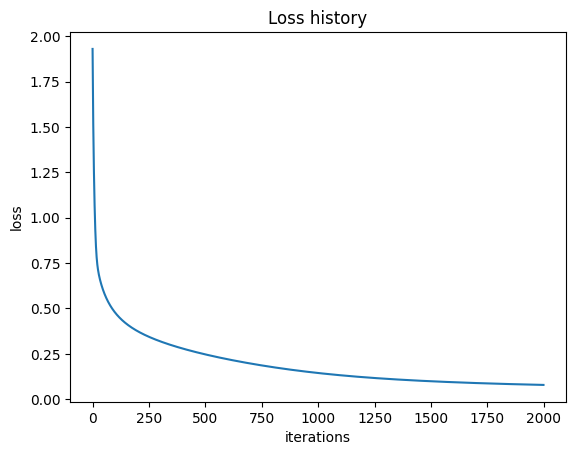

In [43]:
plt.plot(l_history)
plt.title('Loss history')
plt.xlabel('iterations')
plt.ylabel('loss');

In [25]:
y_pred = predict_nn(X, y_enc, params)
accuracy_score(y, y_pred)

0.9733333333333334

Кривая плавная и монотонно убывает — характерный признак полного градиентного спуска (full-batch): градиент считается по всем 150 наблюдениям сразу, без случайных «скачков», которые возникают при мини-батчах.

Резкое падение в первые ~200 эпох сменяется постепенным замедлением: сеть быстро находит нужное направление, затем мелкими шагами уточняет веса.

Точность на обучающей выборке: 97.3% — сеть хорошо разделила все три класса Iris.

### Проверка градиента после инициализации

### Переход от словаря к вектору и обратно

### **Словарь градиентов в вектор**

In [26]:
# на вход функция примет словарь градиентов и
def gradients_to_vector(gradients):

  # создаст массив из "вытянутых" значений словаря
  return np.concatenate([np.reshape(gradients[key], (-1,1)) for key in ['dW1', 'db1', 'dW2', 'db2', 'dW3', 'db3']])

### Словарь параметров в вектор

In [27]:
def dictionary_to_vector(parameters):
  return np.concatenate([np.reshape(parameters[key], (-1,1)) for key in ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']])

### Вектор параметров в словарь

In [28]:
def vector_to_dictionary(theta):

  parameters = {}

  parameters['W1'] = theta[:64].reshape((16,4))
  parameters['b1'] = theta[64:80].reshape((16,1))
  parameters['W2'] = theta[80:336].reshape((16,16))
  parameters['b2'] = theta[336:352].reshape((16,1))
  parameters['W3'] = theta[352:400].reshape((3,16))
  parameters['b3'] = theta[400:403].reshape((3,1))

  return parameters

#### Инициализация параметров

Выполним инициализацию параметров.

In [29]:
parameters = initialize(X, y_enc, random_state = 42)

#### Значение градиента

Найдем фактические значения градиентов при инициализированных параметрах и
поместим их в вектор.

In [30]:
_, cache = forward(X, y_enc, parameters)
_, gradients = backward(X, y_enc, cache)

grad = gradients_to_vector(gradients)
grad.shape

(403, 1)

#### Численная оценка градиента
Выполним численную оценку градиентов. Преобразуем словарь параметров в
вектор.

In [31]:
parameters_values = dictionary_to_vector(parameters)
parameters_values.shape

(403, 1)

Сохраним количество параметров, а также создадим нулевые векторы для $ J(
\theta_j + \varepsilon ), $ $ J(\theta_j-\varepsilon ) $ и $\nabla_{\text{numeric}}
J(\theta).$ Не забудем про константу $\varepsilon.$

In [32]:
num_parameters = parameters_values.shape[0]

J_plus = np.zeros((num_parameters, 1))
J_minus = np.zeros((num_parameters, 1))

gradNumeric = np.zeros((num_parameters, 1))

epsilon = 1e-7

В цикле пройдем по каждому из 403 параметров и для каждого найдем численную
оценку производной.

In [33]:
# будем брать по одному параметру j
for j in range(num_parameters):

  thetaplus = np.copy(parameters_values)
  # добавим epsilon к параметру j
  thetaplus[j][0] = thetaplus[j][0] + epsilon
  # найдем значение целевой функции J(theta) с учетом theta_j + epsilon
  J_plus[j], _ = forward(X, y_enc, vector_to_dictionary(thetaplus))

  thetaminus = np.copy(parameters_values)
  # вычтем epsilon из параметра j
  thetaminus[j][0] = thetaminus[j][0] - epsilon
  # найдем значение целевой функции J(theta) с учетом theta_j - epsilon
  J_minus[j], _ = forward(X, y_enc, vector_to_dictionary(thetaminus))

  # оценим частную производную для данного параметра j
  gradNumeric[j] = (J_plus[j] - J_minus[j]) / (2 * epsilon)

In [34]:
gradNumeric.shape

(403, 1)

#### Сравнение градиента с его численной оценкой
Осталось сравнить фактическое значение градиента с его численной оценкой.

In [35]:
numerator = np.linalg.norm(grad - gradNumeric)
denominator = np.linalg.norm(grad) + np.linalg.norm(gradNumeric)
difference = numerator / denominator
difference, difference < epsilon

(np.float64(3.202186786638279e-08), np.True_)

Аналитически вычисленный градиент (обратное распространение) и численно оценённый градиент (конечные разности) практически идентичны. Это подтверждает корректность реализации backprop.

Поместим приведенный выше код проверки градиента в функции.

In [36]:
def gradient_vector(parameters, x, y):

  _, cache = forward(x, y, parameters)
  _, gradients = backward(x, y, cache)

  return gradients_to_vector(gradients)

In [37]:
def gradNumeric_vector(parameters, x, y, epsilon):

  parameters_values = dictionary_to_vector(parameters)
  num_parameters = parameters_values.shape[0]

  J_plus = np.zeros((num_parameters, 1))
  J_minus = np.zeros((num_parameters, 1))

  gradNumeric = np.zeros((num_parameters, 1))

  for j in range(num_parameters):

    thetaplus = np.copy(parameters_values)
    thetaplus[j][0] = thetaplus[j][0] + epsilon
    J_plus[j], _ = forward(X, y_enc, vector_to_dictionary(thetaplus))

    thetaminus = np.copy(parameters_values)
    thetaminus[j][0] = thetaminus[j][0] - epsilon
    J_minus[j], _ = forward(X, y_enc, vector_to_dictionary(thetaminus))

    gradNumeric[j] = (J_plus[j] - J_minus[j]) / (2 * epsilon)

  return gradNumeric

In [38]:
def difference(grad, gradNumeric):

  numerator = np.linalg.norm(grad - gradNumeric)
  denominator = np.linalg.norm(grad) + np.linalg.norm(gradNumeric)

  return numerator / denominator

In [39]:
def gradient_checking(x, y, random_state, epsilon = 1e-7):

  params = initialize(x, y, random_state)

  grad = gradient_vector(params, x, y)
  gradNumeric = gradNumeric_vector(params, x, y, epsilon)

  diff = difference(grad, gradNumeric)

  return diff, diff < epsilon

In [40]:
gradient_checking(X, y_enc, random_state = 42)

(np.float64(3.202186786638279e-08), np.True_)

### Проверка градиента при обучении

Убедимся, что значение градиента совпадает с его численной оценкой не только
при начальных весах, но и в целом в процессе обучения нейросети.

In [41]:
def fit_nn_with_gradcheck(x, y, epochs = 2000, lr = 0.05,
                          random_state = 42, epsilon = 1e-7):

  # инициализируем параметры
  parameters = initialize(x, y, random_state)

  # в цикле
  for i in range(epochs):

    # сохраним текущие параметры (для проверки градиента)
    current_parameters = parameters.copy()

    # выполним прямое и
    loss, cache = forward(x, y, parameters)
    # обратное распространение, получив градиенты, а также
    # обновленные параметры (для дальнейшего обучения)
    parameters, gradients = backward(x, y, cache, lr)

    # периодически
    if i % (epochs / 5) == 0:
      print('Эпоха:', i)
      print('Ошибка:', loss)

      # создадим вектор градиентов, а также
      grad = gradients_to_vector(gradients)
      # вектор численной оценки градиентов на основе текущих параметров,
      gradNumeric = gradNumeric_vector(current_parameters, x, y, epsilon)
      # сравним эти векторы
      diff = difference(grad, gradNumeric)
      # и выведем результат сравнения
      print('Отклонение градиента:', diff)
      print('Проверка градиента пройдена:', diff < epsilon)
      print('-----------------------')

  print('Итоговая ошибка', loss)
  print('Нейросеть успешно обучена')

  return None

In [42]:
fit_nn_with_gradcheck(X, y_enc)

Эпоха: 0
Ошибка: 1.9302802579995444
Отклонение градиента: 3.202186786638279e-08
Проверка градиента пройдена: True
-----------------------
Эпоха: 400
Ошибка: 0.2789931998947429
Отклонение градиента: 2.7367471607875584e-08
Проверка градиента пройдена: True
-----------------------
Эпоха: 800
Ошибка: 0.17656405678666656
Отклонение градиента: 2.124338835044995e-08
Проверка градиента пройдена: True
-----------------------
Эпоха: 1200
Ошибка: 0.1214353432859518
Отклонение градиента: 2.026309679899874e-08
Проверка градиента пройдена: True
-----------------------
Эпоха: 1600
Ошибка: 0.09368719381588529
Отклонение градиента: 2.4502830655817592e-08
Проверка градиента пройдена: True
-----------------------
Итоговая ошибка 0.07880538313917614
Нейросеть успешно обучена


Проверки пройдены успешно.